<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Predict_Credit_Card_Approvals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 3 : Predict Credit Card Approvals**

**Objective**

Build a machine learning classification system that predicts whether a credit card application will be approved or rejected based on applicant information.

**This project focuses on:**

Handling missing values

Processing categorical data

Feature scaling

Managing imbalanced datasets

Logistic Regression

Hyperparameter optimization using GridSearchCV

This simulates a real-world banking and financial risk assessment system.

# **1. Problem Statement**

Banks and financial institutions receive thousands of credit card applications daily. Manual verification is time-consuming and prone to human bias.

The goal is to automate the approval process using machine learning.

The model predicts:

                    Approved→1
                    Rejected→0

# **2. Machine Learning Workflow**


Data Collection

      ↓
Data Cleaning

      ↓
Handle Missing Values

      ↓
Encode Categorical Features

      ↓
Feature Scaling

      ↓
Handle Imbalanced Data

      ↓
Train Logistic Regression Model

      ↓
Hyperparameter Optimization

      ↓
Model Evaluation

      ↓
Approval Prediction

# **3. Dataset**

**Recommended Dataset:**

UCI Credit Card Approval Dataset

# **4. Install Required Libraries**

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

# **5. Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

# **6. Load Dataset**

In [3]:
df = pd.read_csv("credit_card_approval.csv")

print(df.head())

   b  30.83      0  u  g  w  v  1.25  t t.1  1  f g.1  202  0.1  +
0  a  58.67  4.460  u  g  q  h  3.04  t   t  6  f   g   43  560  +
1  a   24.5  0.500  u  g  q  h  1.50  t   f  0  f   g  280  824  +
2  b  27.83  1.540  u  g  w  v  3.75  t   t  5  t   g  100    3  +
3  b  20.17  5.625  u  g  w  v  1.71  t   f  0  f   s  120    0  +
4  b  32.08  4.000  u  g  m  v  2.50  t   f  0  t   g  360    0  +


# **7. Handle Missing Values**

**Check Missing Values**

In [4]:
print(df.isnull().sum())

b        0
30.83    0
0        0
u        0
g        0
w        0
v        0
1.25     0
t        0
t.1      0
1        0
f        0
g.1      0
202      0
0.1      0
+        0
dtype: int64


**Fill Numerical Missing Values**

In [5]:
num_cols = df.select_dtypes(include=np.number).columns

imputer_num = SimpleImputer(strategy='mean')

df[num_cols] = imputer_num.fit_transform(df[num_cols])

**Fill Categorical Missing Values**

In [6]:
cat_cols = df.select_dtypes(include='object').columns

imputer_cat = SimpleImputer(strategy='most_frequent')

df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# **8. Encode Categorical Features**

In [7]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

# **9. Feature Selection**

**Input Features**

In [14]:
X = df.drop('+', axis=1)

# **Target Variable**

In [16]:
y = df['+']

# **10. Handle Imbalanced Data**

**Check Class Distribution**

In [17]:
print(y.value_counts())

+
1    383
0    306
Name: count, dtype: int64


# **Apply SMOTE**

**SMOTE generates synthetic samples for minority class balancing.**

In [18]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# **11. Feature Scaling**

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

# **12. Train-Test Split**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

# **13. Build Logistic Regression Model**

In [21]:
model = LogisticRegression()

# **14. Hyperparameter Optimization using GridSearchCV**

**Parameter Grid**

In [22]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

**Grid Search**

In [23]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 200, 500],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

**Best Parameters**

In [24]:
print("Best Parameters:",
      grid_search.best_params_)

Best Parameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}


# **15. Best Model**

In [25]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

# **16. Model Evaluation**

**Accuracy**

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8636363636363636


# **Confusion Matrix**

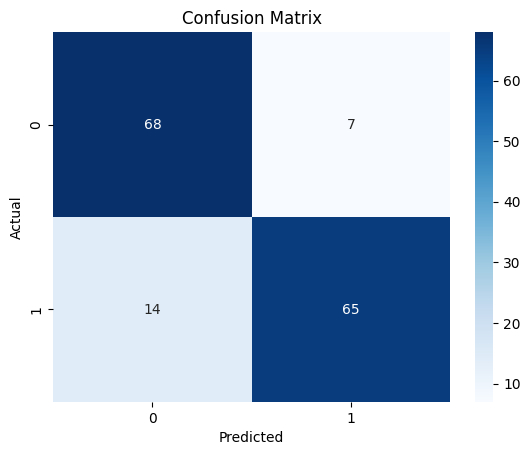

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Classification Report**

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        75
           1       0.90      0.82      0.86        79

    accuracy                           0.86       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.87      0.86      0.86       154



# **17. Predict New Application**

In [31]:
new_applicant_data = [[
    1,      # Gender (A1)
    35,     # Age (A2)
    5000,   # Debt (A3)
    1,      # Married (A4)
    1,      # BankCustomer (A5)
    2,      # EducationLevel (A6)
    1,      # Ethnicity (A7)
    7,      # YearsEmployed (A8)
    0,      # PriorDefault (A9)
    1,      # Employed (A10)
    750,    # CreditScore (A11)
    1,      # DriversLicense (A12)
    0,      # Citizenship (A13 - Placeholder value, assumed encoded)
    0,      # Postal Code (A14 - Placeholder value)
    60000   # Income (A15)
]]

# Create a DataFrame for the new applicant with the same columns as X
new_applicant_df = pd.DataFrame(new_applicant_data, columns=X.columns)

new_scaled = scaler.transform(new_applicant_df)

prediction = best_model.predict(new_scaled)

if prediction[0] == 1:
    print("Credit Card Approved")
else:
    print("Credit Card Rejected")

Credit Card Rejected


# **18. Important Concepts Learned**

**This project teaches:**

Classification algorithms

Logistic Regression

Missing value handling

Categorical encoding

Feature scaling

Imbalanced dataset handling

SMOTE oversampling

Hyperparameter optimization

GridSearchCV

Model evaluation

# **19. Logistic Regression Formula**


P(y=1)=
1+e
−(β
0	​
+β
1	​
x
1	​
+⋯+β
n	​
x
n
)
1
	​


This formula predicts the probability of approval.

# **20. Why Use Feature Scaling?**

Logistic Regression performs better when features are normalized.

**Standardization formula:**

z=\frac{x-\mu}{\sigma}



# **21. Advanced Improvements**

**You can improve this project using:**

**Advanced Models**

Random Forest Classifier

XGBoost Classifier

CatBoost

Neural Networks

**Better Techniques**

Feature selection

PCA dimensionality reduction

Cross-validation pipelines

ROC-AUC optimization

**Deployment**

Streamlit approval app

Flask API

Real-time banking dashboard

# **22. Interview Questions**

**Why use Logistic Regression?**

Because this is a binary classification problem.

**What is SMOTE?**

SMOTE balances datasets by creating synthetic minority samples.

**Why use GridSearchCV?**

GridSearchCV automatically finds the best hyperparameters.

**Why scale features?**

Scaling prevents features with larger values from dominating the model.

# **24. Resume Description**

Developed a machine learning-based credit card approval prediction system using Logistic Regression and hyperparameter optimization to automate financial decision-making with high classification accuracy.

# **25. Results & Learning Outcomes**

Through this project, I successfully developed an automated credit card approval prediction system using machine learning classification techniques. I learned how to preprocess complex real-world financial datasets, handle missing values, encode categorical variables, scale features, and manage imbalanced data using SMOTE.

**This project improved my understanding of:**


Logistic Regression for binary classification


Data preprocessing and cleaning


Handling missing values


Feature scaling and normalization


Imbalanced dataset handling using SMOTE


Hyperparameter optimization using GridSearchCV


Model evaluation using accuracy, confusion matrix, and classification report


Financial risk prediction systems


The project also strengthened my practical skills in:


Python programming


Pandas and NumPy


Scikit-learn machine learning pipeline


Hyperparameter tuning


Classification model development


Predictive analytics in banking and finance


Overall, this project provided hands-on experience in building a real-world automated approval system capable of assisting banks and financial institutions in faster and more accurate decision-making.